In [1]:
# analysis_visuals.ipynb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import pandas as pd
from model import AutoEncoder
from preprocess import load_and_preprocess
from config import AE_MODEL_PATH, THRESHOLD_PATH

# ======================================================
# 1. Load data and model
# ======================================================

In [2]:
print("Loading test data and trained AutoEncoder...")
X_train, y_train, X_test, y_test = load_and_preprocess()

input_dim = X_test.shape[1]
model = AutoEncoder(input_dim)
model.load_state_dict(torch.load(AE_MODEL_PATH, map_location='cpu'))
model.eval()

Loading test data and trained AutoEncoder...


AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=122, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=122, bias=True)
    (5): Sigmoid()
  )
)

# ======================================================
# 2. Compute reconstruction errors
# ======================================================

In [3]:
print("Computing reconstruction errors...")
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    X_recon = model(X_test_tensor).numpy()

recon_error = np.mean((X_test - X_recon) ** 2, axis=1)

normal_errors = recon_error[y_test == 0]
anomaly_errors = recon_error[y_test == 1]

Computing reconstruction errors...


# ======================================================
# 3. Plot KDE of reconstruction errors
# ======================================================

Plotting reconstruction error distributions...


/Users/nigorakhonganieva/miniforge3/envs/data-science/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/nigorakhonganieva/miniforge3/envs/data-science/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


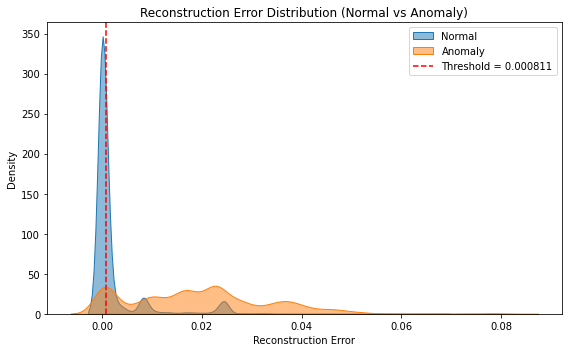

In [4]:
print("Plotting reconstruction error distributions...")
threshold = np.load(THRESHOLD_PATH)  # previously saved during training

plt.figure(figsize=(8, 5))
sns.kdeplot(normal_errors, label="Normal", fill=True, alpha=0.5)
sns.kdeplot(anomaly_errors, label="Anomaly", fill=True, alpha=0.5)
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold = {threshold:.6f}')
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution (Normal vs Anomaly)")
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 4. Fine-tune threshold for best F1-score
# ======================================================

Finding optimal threshold for balanced Precision/Recall...
Optimal Threshold: 0.000930
Best F1-Score: 0.8605


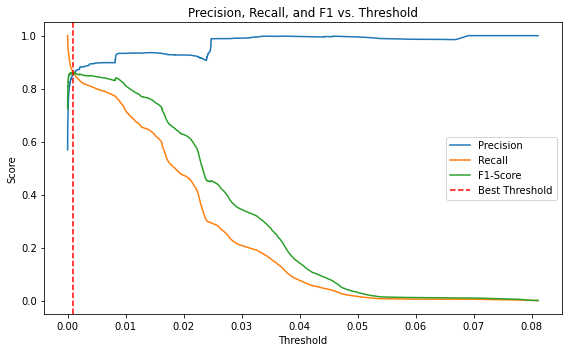

In [5]:
print("Finding optimal threshold for balanced Precision/Recall...")
precision, recall, thresholds = precision_recall_curve(y_test, recon_error)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.6f}")
print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")

# Optional: visualize precision-recall tradeoff
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.axvline(best_threshold, color='r', linestyle='--', label='Best Threshold')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs. Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 5. Evaluate with new threshold
# ======================================================

In [6]:
print("Re-evaluating AutoEncoder with optimized threshold...")
y_pred_opt = (recon_error > best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt, digits=4))

Re-evaluating AutoEncoder with optimized threshold...
[[ 7869  1842]
 [ 1752 11081]]
              precision    recall  f1-score   support

           0     0.8179    0.8103    0.8141      9711
           1     0.8575    0.8635    0.8605     12833

    accuracy                         0.8406     22544
   macro avg     0.8377    0.8369    0.8373     22544
weighted avg     0.8404    0.8406    0.8405     22544



# ======================================================
# 6. Compare with MLP baseline
# ======================================================

Comparing AutoEncoder and Baseline MLP...


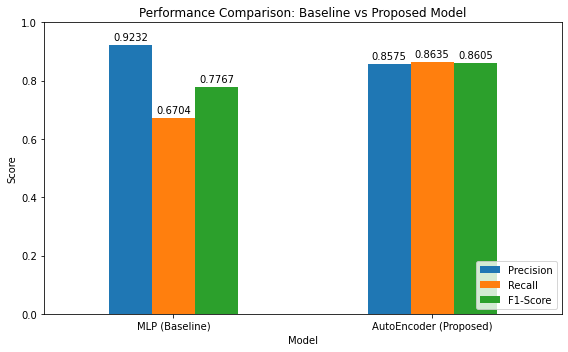

All visualizations completed successfully!


In [7]:
print("Comparing AutoEncoder and Baseline MLP...")

mlp_metrics = {"Precision": 0.9232, "Recall": 0.6704, "F1-Score": 0.7767}

report = classification_report(
    y_test,
    y_pred_opt,
    output_dict=True
)

ae_metrics = {
    "Precision": report["1"]["precision"],
    "Recall": report["1"]["recall"],
    "F1-Score": report["1"]["f1-score"]
}

df_compare = pd.DataFrame({
    "Model": ["MLP (Baseline)", "AutoEncoder (Proposed)"],
    "Precision": [mlp_metrics["Precision"], ae_metrics["Precision"]],
    "Recall": [mlp_metrics["Recall"], ae_metrics["Recall"]],
    "F1-Score": [mlp_metrics["F1-Score"], ae_metrics["F1-Score"]],
})

# Plot
ax = df_compare.plot(x="Model", kind="bar", figsize=(8, 5), rot=0)

plt.ylim(0, 1)
plt.title("Performance Comparison: Baseline vs Proposed Model")
plt.ylabel("Score")
plt.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

print("All visualizations completed successfully!")